# PV-gradient and eddy-tilt direction case studies

This notebook automatically finds clear examples of the polarity-dependent relationship between eddy tilt and the ambient shallow-water PV gradient. The working hypotheses are:

- In the planetary-beta-dominant open ocean, cyclonic eddies (CEs) preferentially tilt **along** the PV gradient, whereas anticyclonic eddies (AEs) preferentially tilt **opposite** it.
- On strong topographic gradients, CEs continue to align as the total PV gradient rotates toward the topographic contribution.
- Topographic-dominant AEs show weaker or inconsistent directional preference.

Candidates are selected automatically, but the final figures must still be checked for coherent tracks, data coverage, coastline effects, and physically meaningful transitions.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

HERE = Path.cwd().resolve()
ANALYSIS_ROOT = next(
    (p for p in (HERE, *HERE.parents) if (p / 'seacofs_tilt_tools.py').exists()),
    None,
)
if ANALYSIS_ROOT is None:
    raise FileNotFoundError('Run from seacofs_eddy_tilt_analysis or one of its subfolders.')
CASE_ROOT = ANALYSIS_ROOT / 'case_studies'
for path in (CASE_ROOT, ANALYSIS_ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import seacofs_tilt_tools as tilt
from case_study_tools import (
    PVAlignmentConfig,
    plot_pv_alignment_case,
    rank_pv_alignment_cases,
    select_pv_alignment_cases,
)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)

## 1. Load PV-gradient diagnostics

The primary screen uses core-mean bathymetry and bathymetric gradients. Direction is considered reliable only when tilt distance is at least 5 km; very small displacement vectors have unstable bearings and should not drive case selection.

In [2]:
paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
df_eddies, _ = tilt.load_tilt_tables(paths)
df_eddies = tilt.add_region_labels(df_eddies, grid)
df_eddies = tilt.add_pv_gradient_terms(df_eddies, grid, core_mean=True)

required = {
    'Eddy', 'Day', 'Cyc', 'h', 'TiltDis', 'TiltDir',
    'PV_grad_theta', 'PV_grad_mag', 'PV_grad_plan_mag',
    'PV_grad_topo_mag', 'dtheta_PV_grad', 'topo_plan_ratio',
}
missing = required - set(df_eddies.columns)
if missing:
    raise KeyError(f'Missing required columns: {sorted(missing)}')
if df_eddies.duplicated(['Eddy', 'Day']).any():
    raise ValueError('Expected one row per Eddy-Day.')

print(f"{len(df_eddies):,} observations from {df_eddies.Eddy.nunique():,} eddies")
display(df_eddies.groupby('Cyc').agg(observations=('Eddy', 'size'), eddies=('Eddy', 'nunique')))

127,426 observations from 2,982 eddies


,observations,eddies
Cyc,,
AE,64952,1446
CE,62474,1536


## 2. Selection criteria

Planetary or topographic dominance requires the relevant PV-gradient magnitude to be at least twice the competing contribution. Open-ocean candidates must additionally have core-mean depth of at least 2,000 m. Alignment and opposition allow a ±45° tolerance.

The ranking rewards sustained behaviour, not isolated matching observations. It also rewards long lifetime, time spent in the target regime, directional-data coverage, and small typical target error. AE and CE open-ocean cases are ranked separately.

In [3]:
MIN_OPEN_OCEAN_DEPTH_m = 3000.0
MAX_TOPO_DEPTH_m = 3000.0
config = PVAlignmentConfig(
    smooth_window=7,
    min_periods=5,
    min_lifetime_days=60,
    min_valid_observations=20,
    min_regime_observations=10,
    min_sustained_run=5,
    dominance_factor=2.0,
    angle_tolerance_deg=45.0,
    min_open_ocean_depth_m=MIN_OPEN_OCEAN_DEPTH_m,
    max_topo_depth_m=MAX_TOPO_DEPTH_m,
    min_tilt_distance_km=5.0,
)

df_direction, ranking = rank_pv_alignment_cases(df_eddies, config)
display(
    ranking.groupby('ranking_group')['eligible']
    .agg(candidates='size', eligible='sum')
)

,candidates,eligible
ranking_group,,
open_ocean_ae,1446,54
open_ocean_ce,1536,6
topographic_ae_no_preference,1446,211
topographic_ce_alignment,1536,159


## 3. Ranked case-study candidates

The four groups are: open-ocean AE opposition, open-ocean CE alignment, topographic CE alignment, and topographic AE directional dispersion. For the AE topographic group, lower circular resultant length means that relative directions are more dispersed and therefore show less directional preference.

In [4]:
ranking_columns = [
    'Eddy', 'Cyc', 'Region', 'case_score', 'lifetime_days',
    'regime_observations', 'regime_fraction', 'longest_regime_run',
    'matching_fraction', 'longest_matching_run',
    'median_target_error_deg', 'relative_angle_resultant',
    'alignment_fraction', 'opposition_fraction',
    'directional_coverage', 'median_tilt_km', 'median_depth_m',
]
group_titles = {
    'open_ocean_ce': 'Open-ocean CE alignment',
    'open_ocean_ae': 'Open-ocean AE opposition',
    'topographic_ce_alignment': 'Topographic CE alignment',
    'topographic_ae_no_preference': 'Topographic AE weak preference',
}
for group, label in group_titles.items():
    print(f'\n{label}')
    display(
        ranking.loc[(ranking.ranking_group == group) & ranking.eligible, ranking_columns]
        .head(20).round(3)
)


Open-ocean CE alignment


,Eddy,Cyc,Region,case_score,lifetime_days,regime_observations,regime_fraction,longest_regime_run,matching_fraction,longest_matching_run,median_target_error_deg,relative_angle_resultant,alignment_fraction,opposition_fraction,directional_coverage,median_tilt_km,median_depth_m
1446,1856,CE,D1,0.976,66.0,16,0.239,10,1.000,10,20.179,NaN,NaN,NaN,0.910,13.505,4835.868
1447,1590,CE,D2,0.975,83.0,13,0.155,8,0.923,8,14.979,NaN,NaN,NaN,0.929,14.873,4598.923
1448,639,CE,D1,0.967,62.0,11,0.175,11,0.818,8,24.756,NaN,NaN,NaN,0.905,16.102,4867.868
1449,1570,CE,D1,0.966,68.0,12,0.174,12,1.000,12,12.894,NaN,NaN,NaN,0.855,8.019,4846.138
1450,2027,CE,D2,0.966,92.0,34,0.366,34,0.382,10,64.333,NaN,NaN,NaN,0.882,16.519,4644.946
1451,2808,CE,D1,0.919,86.0,23,0.264,10,0.652,10,33.265,NaN,NaN,NaN,0.736,8.243,4863.791



Open-ocean AE opposition


,Eddy,Cyc,Region,case_score,lifetime_days,regime_observations,regime_fraction,longest_regime_run,matching_fraction,longest_matching_run,median_target_error_deg,relative_angle_resultant,alignment_fraction,opposition_fraction,directional_coverage,median_tilt_km,median_depth_m
0,150,AE,D1,0.969,76.0,27,0.351,27,0.963,26,21.173,NaN,NaN,NaN,0.922,21.028,4849.917
1,1338,AE,D2,0.968,72.0,26,0.356,26,0.962,25,11.026,NaN,NaN,NaN,0.918,26.381,4644.974
2,356,AE,S2,0.965,243.0,64,0.262,55,0.719,41,30.253,NaN,NaN,NaN,0.906,22.290,4875.985
3,1060,AE,D1,0.962,100.0,29,0.287,22,0.793,22,21.342,NaN,NaN,NaN,0.901,21.256,4827.769
4,493,AE,D1,0.962,122.0,30,0.244,27,0.833,20,25.415,NaN,NaN,NaN,0.894,11.190,4837.933
5,1912,AE,D1,0.957,84.0,76,0.894,67,0.553,12,42.559,NaN,NaN,NaN,0.906,21.338,4858.559
6,604,AE,D1,0.951,138.0,73,0.525,71,0.315,14,48.659,NaN,NaN,NaN,0.914,19.764,4853.277
7,1616,AE,D1,0.949,109.0,66,0.600,55,0.394,16,74.682,NaN,NaN,NaN,0.909,17.810,4831.528
8,429,AE,D2,0.947,87.0,19,0.216,15,0.789,8,34.533,NaN,NaN,NaN,0.932,30.454,4655.237
9,739,AE,D1,0.946,142.0,12,0.084,12,1.000,12,6.177,NaN,NaN,NaN,0.888,37.138,4664.931



Topographic CE alignment


,Eddy,Cyc,Region,case_score,lifetime_days,regime_observations,regime_fraction,longest_regime_run,matching_fraction,longest_matching_run,median_target_error_deg,relative_angle_resultant,alignment_fraction,opposition_fraction,directional_coverage,median_tilt_km,median_depth_m
4428,735,CE,U2,0.968,83.0,78,0.929,78,0.987,77,22.944,NaN,NaN,NaN,0.929,52.878,2006.137
4429,1034,CE,U2,0.966,70.0,65,0.915,65,0.985,55,15.662,NaN,NaN,NaN,0.915,22.591,2400.040
4430,2155,CE,D2,0.949,82.0,73,0.880,44,0.904,44,16.597,NaN,NaN,NaN,0.880,16.101,3781.774
4431,1194,CE,U2,0.941,124.0,117,0.936,66,0.744,57,32.209,NaN,NaN,NaN,0.936,27.214,2413.615
4432,1803,CE,U2,0.935,90.0,84,0.923,68,0.726,46,30.742,NaN,NaN,NaN,0.923,32.088,1908.603
4433,2882,CE,U2,0.933,80.0,75,0.926,75,0.733,31,30.756,NaN,NaN,NaN,0.926,15.356,3147.163
4434,2600,CE,U2,0.932,65.0,60,0.909,60,0.733,41,22.236,NaN,NaN,NaN,0.909,60.207,2418.457
4435,13,CE,U2,0.932,106.0,101,0.944,101,0.683,58,36.156,NaN,NaN,NaN,0.944,32.241,2357.532
4436,596,CE,S1,0.926,99.0,94,0.940,94,0.649,54,34.104,NaN,NaN,NaN,0.940,23.496,2875.889
4437,376,CE,S1,0.917,74.0,65,0.867,43,0.708,40,20.126,NaN,NaN,NaN,0.867,17.260,2948.072



Topographic AE weak preference


,Eddy,Cyc,Region,case_score,lifetime_days,regime_observations,regime_fraction,longest_regime_run,matching_fraction,longest_matching_run,median_target_error_deg,relative_angle_resultant,alignment_fraction,opposition_fraction,directional_coverage,median_tilt_km,median_depth_m
2982,2517,AE,U2,0.979,164.0,152,0.921,56,0.804,56,87.547,0.196,0.197,0.283,0.945,26.230,2666.500
2983,2442,AE,U2,0.970,73.0,68,0.919,68,0.805,68,114.989,0.195,0.235,0.338,0.919,43.126,2949.137
2984,1457,AE,U2,0.956,73.0,62,0.838,62,0.838,62,137.403,0.162,0.306,0.516,0.878,36.070,3258.777
2985,2790,AE,U1,0.956,183.0,157,0.853,107,0.688,107,79.036,0.312,0.255,0.146,0.913,16.931,4227.739
2986,396,AE,U2,0.954,97.0,85,0.867,42,0.757,42,103.678,0.243,0.424,0.353,0.918,21.163,2468.114
2987,2470,AE,U2,0.950,61.0,56,0.903,56,0.743,56,106.378,0.257,0.339,0.321,0.903,19.039,3558.641
2988,1824,AE,U1,0.948,145.0,113,0.774,63,0.790,63,69.371,0.210,0.398,0.195,0.897,16.579,4347.825
2989,2235,AE,D2,0.944,126.0,101,0.795,68,0.798,68,73.818,0.202,0.356,0.119,0.850,16.605,3690.175
2990,73,AE,U2,0.943,62.0,56,0.889,55,0.726,55,100.391,0.274,0.143,0.179,0.889,27.425,2426.842
2991,495,AE,U2,0.942,114.0,108,0.939,88,0.598,88,89.602,0.402,0.176,0.231,0.939,28.561,2634.644


## 4. Population context before selecting individual eddies

These distributions show whether the selected cases sit within the broader polarity-dependent signal. They help prevent the case studies from being interpreted as the only behaviour in the dataset.

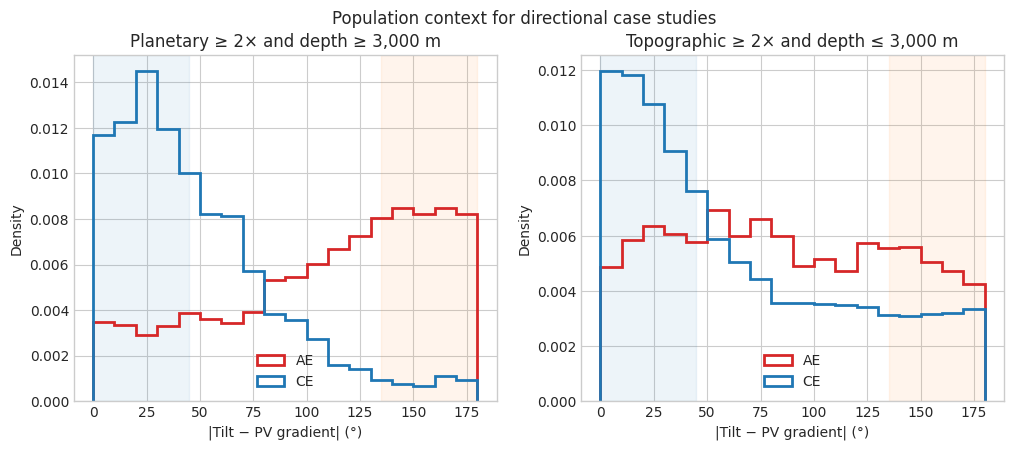

In [5]:
planetary = df_direction[df_direction.open_ocean_planetary & df_direction.direction_valid]
topographic = df_direction[df_direction.shallow_ocean_topographic & df_direction.direction_valid]
bins = np.arange(0, 181, 10)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)
for cyc, color in [('AE', 'tab:red'), ('CE', 'tab:blue')]:
    axes[0].hist(planetary.loc[planetary.Cyc == cyc, 'dtheta_PV_grad'], bins=bins,
                 density=True, histtype='step', lw=2, color=color, label=cyc)
    axes[1].hist(topographic.loc[topographic.Cyc == cyc, 'dtheta_PV_grad'], bins=bins,
                 density=True, histtype='step', lw=2, color=color, label=cyc)
for ax, title in zip(axes, ['Planetary ≥ 2×' if MIN_OPEN_OCEAN_DEPTH_m==0.0 else f'Planetary ≥ 2× and depth ≥ {MIN_OPEN_OCEAN_DEPTH_m:,.0f} m',
                            'Topographic ≥ 2×' if MAX_TOPO_DEPTH_m==0.0 else f'Topographic ≥ 2× and depth ≤ {MAX_TOPO_DEPTH_m:,.0f} m']):
    ax.axvspan(0, 45, color='tab:blue', alpha=.08)
    ax.axvspan(135, 180, color='tab:orange', alpha=.08)
    ax.set(title=title, xlabel='|Tilt − PV gradient| (°)', ylabel='Density')
    ax.legend(frameon=False)
fig.suptitle('Population context for directional case studies');

#### Planetary analysis ($\geq2\times$)

AE mean tilt dir 18,    tilt dis 21 km
CE mean tilt dir 154,    tilt dis 20 km
Planetary ≥ 2× and depth ≥ 3,000 m


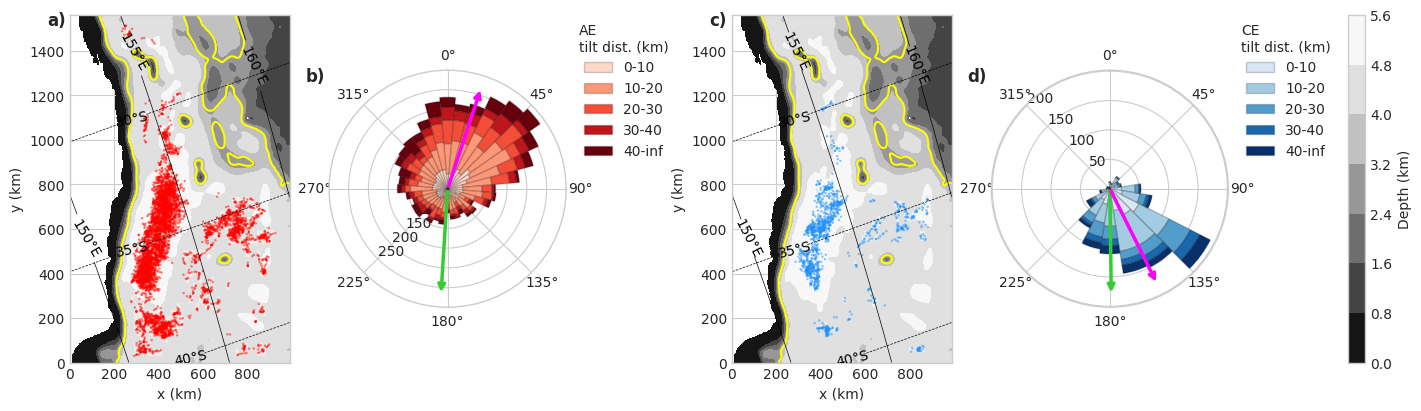

In [6]:
fig = plt.figure(figsize=(14, 4), constrained_layout=True)

axs = [
    fig.add_subplot(1, 4, 1),
    fig.add_subplot(1, 4, 2, projection='polar'),
    fig.add_subplot(1, 4, 3),
    fig.add_subplot(1, 4, 4, projection='polar')
]

mag_bins = [0, 10, 20, 30, 40, np.inf]

for i, cyc in enumerate(['AE', 'CE']):
    ax, axw = axs[2*i], axs[2*i+1]
    df = planetary[planetary.Cyc == cyc].copy()
    cmap = 'Reds' if cyc == 'AE' else 'Blues'
    col = 'r' if cyc == 'AE' else 'dodgerblue'
    colors = getattr(plt.cm, cmap)(np.linspace(.15, 1, len(mag_bins)-1))

    # Map
    bath = ax.contourf(
        grid.X_grid, grid.Y_grid,
        np.where(grid.mask_rho, grid.h/1e3, np.nan),
        cmap='Greys_r'
    )

    ax.hist2d(df.xc, df.yc, bins=50, cmap=cmap, alpha=.6, cmin=2)
    ax.scatter(df.xc, df.yc, s=3, c=col, alpha=.5, edgecolors='none')
    ax.contour(grid.X_grid, grid.Y_grid, grid.h,
               levels=[MIN_OPEN_OCEAN_DEPTH_m], colors='yellow')

    tilt.lat_lon_contours(ax, grid)
    ax.set_xlabel('x (km)'); ax.set_ylabel('y (km)')
    ax.set_xlim(grid.X_grid.min(), grid.X_grid.max())
    ax.set_ylim(grid.Y_grid.min(), grid.Y_grid.max())

    ax.set_aspect('equal', adjustable='box')

    # Windrose
    df = df.dropna(subset=['TiltDir', 'TiltDis'])
    tilt.plot_windrose(axw, df, title='', mag_bins=mag_bins, colors=colors)#, rotate=20)

    # PV arrow
    theta = np.deg2rad(
        planetary.loc[planetary.Cyc == cyc, 'PV_grad_theta'].dropna()
    )
    theta_mean = np.arctan2(np.mean(np.sin(theta)), np.mean(np.cos(theta)))
    rmax = axw.get_ylim()[1]
    axw.annotate(
        '',
        xy=(theta_mean, 0.9*rmax),
        xytext=(theta_mean, 0),
        arrowprops=dict(arrowstyle='->', lw=2.5, color='limegreen')
    )

    # tilt arrow
    theta = np.deg2rad(
        planetary.loc[planetary.Cyc == cyc, 'TiltDir'].dropna()
    )
    theta_mean = np.arctan2(np.mean(np.sin(theta)), np.mean(np.cos(theta)))
    print(f'{cyc} mean tilt dir {np.rad2deg(theta_mean):.0f},\
    tilt dis {planetary[planetary.Cyc==cyc].TiltDis.mean():.0f} km')
    axw.annotate(
        '',
        xy=(theta_mean, 0.9*rmax),
        xytext=(theta_mean, 0),
        arrowprops=dict(arrowstyle='->', lw=2.5, color='magenta')
    )
    
    axw.legend(
        title=f'{cyc}\ntilt dist. (km)',
        loc='upper left',
        bbox_to_anchor=(1.0, 1.25),
        frameon=False
    )

# Single bathymetry colourbar
cbar = fig.colorbar(bath, ax=axs, orientation='vertical',
                    fraction=.02, pad=.01)
cbar.set_label('Depth (km)')

for ax, label in zip(axs, ['a)', 'b)', 'c)', 'd)']):
    ax.text(-0.1, 1.01, label,
            transform=ax.transAxes,
            ha='left', va='top',
            fontsize=12, fontweight='bold')

print('Planetary ≥ 2×' if MIN_OPEN_OCEAN_DEPTH_m==0.0 else f'Planetary ≥ 2× and depth ≥ {MIN_OPEN_OCEAN_DEPTH_m:,.0f} m')
plt.show()

This leads me to believe there is an equal eastward tilt compoenent being imposed on both AEs and CEs. The means tilt directions from the y axis is roughly equal $18 (CE)\approx26^\circ (AE)$. Recall AE tilt more hence why the angle is bigger for AE.

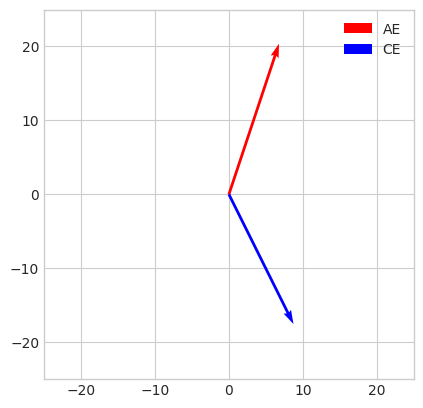

In [7]:
fig, ax = plt.subplots()

for cyc, c in zip(['AE', 'CE'], ['r', 'b']):
    d = planetary[planetary.Cyc == cyc].dropna(subset=['TiltDir', 'TiltDis'])
    th = np.deg2rad(d.TiltDir)
    th = np.arctan2(np.mean(np.sin(th)), np.mean(np.cos(th)))
    mag = d.TiltDis.mean()

    x = mag * np.sin(th)
    y = mag * np.cos(th)

    ax.quiver(0, 0, x, y, angles='xy', scale_units='xy', scale=1, color=c, label=cyc)

ax.set_aspect('equal')
ax.set_xlim(-25,25)
ax.set_ylim(-25,25)
ax.legend()

(-30.0, 30.0)

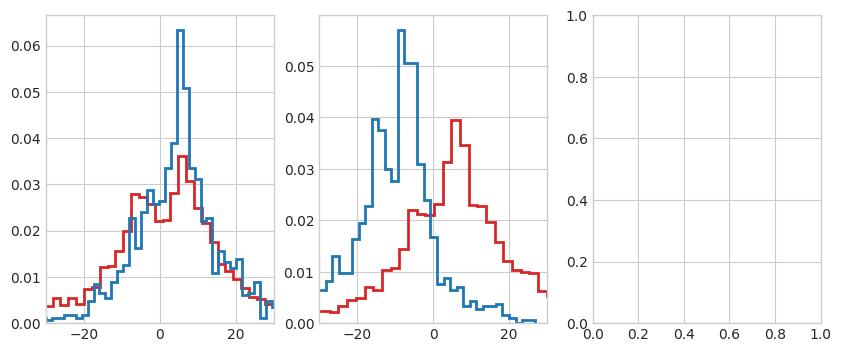

In [8]:
df = planetary.copy()

df["x"] = df["TiltDis"] * np.sin(np.deg2rad(df["TiltDir"]))
df["y"] = df["TiltDis"] * np.cos(np.deg2rad(df["TiltDir"]))
fig, axs = plt.subplots(1,3, figsize=(10,4))
for cyc in ['AE', 'CE']:
    cmap = 'Reds' if cyc == 'AE' else 'Blues'
    col = 'tab:red' if cyc == 'AE' else 'tab:blue'
    colors = getattr(plt.cm, cmap)(np.linspace(.15, 1, len(mag_bins)-1))
    axs[0].hist(df.loc[df.Cyc == cyc, 'x'], bins=100,
                 density=True, histtype='step', lw=2, color=col, label=cyc)
    axs[1].hist(df.loc[df.Cyc == cyc, 'y'], bins=100,
                 density=True, histtype='step', lw=2, color=col, label=cyc)
axs[0].set_xlim(-30,30)
axs[1].set_xlim(-30,30)

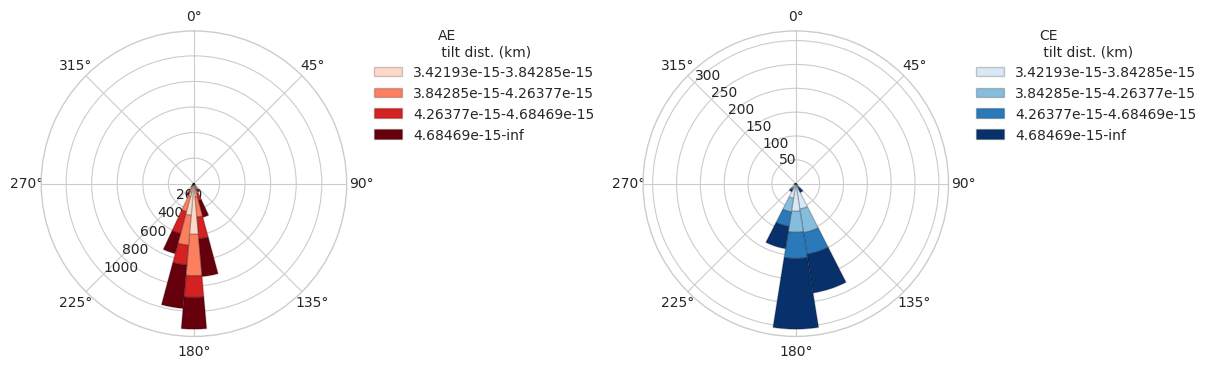

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(12, 7), subplot_kw={"projection": "polar"}, constrained_layout=True)
mag_bins = np.r_[
    np.linspace(
        planetary.PV_grad_mag.describe()["25%"],
        planetary.PV_grad_mag.describe()["75%"],
        4
    ),
    np.inf
]
for ax, cyc, colors in zip(axs, ["AE", "CE"], [plt.cm.Reds(np.linspace(0.15, 1, len(mag_bins) - 1)), plt.cm.Blues(np.linspace(0.15, 1, len(mag_bins) - 1))]):
    subset = planetary.loc[planetary.Cyc == cyc].dropna(subset=["PV_grad_theta", "PV_grad_mag"])
    tilt.plot_windrose(ax, subset, title='', mag_bins=mag_bins, colors=colors, mag='PV_grad_mag', theta='PV_grad_theta')
    ax.legend(title=f"{cyc}\n tilt dist. (km)", loc="upper left", bbox_to_anchor=(1.05, 1.05), frameon=False)
    # ax.set_rticks([])
plt.show()

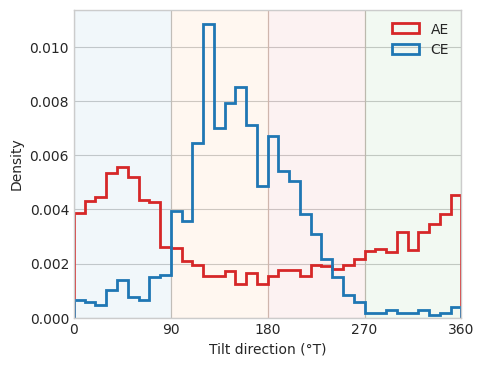

In [10]:
fig, ax = plt.subplots(figsize=(5, 4), sharey=False)

# Light shading for directional quadrants
ax.axvspan(0,   90,  color='tab:blue', alpha=0.06, label='_nolegend_')   # NE
ax.axvspan(90,  180, color='tab:orange', alpha=0.06, label='_nolegend_') # SE
ax.axvspan(180, 270, color='tab:red', alpha=0.06, label='_nolegend_')    # SW
ax.axvspan(270, 360, color='tab:green', alpha=0.06, label='_nolegend_')  # NW
bins = np.arange(0, 361, 10)
for cyc, color in [('AE', 'tab:red'), ('CE', 'tab:blue')]:
    ax.hist(planetary.loc[planetary.Cyc == cyc, 'TiltDir'], bins=bins,
            density=True, histtype='step', lw=2, color=color, label=cyc)
ax.set_xlim(0, 360); ax.set_xticks([0, 90, 180, 270, 360]); ax.set_xlabel('Tilt direction (°T)')
ax.set_ylabel('Density'); ax.legend()

#### topographic analysis

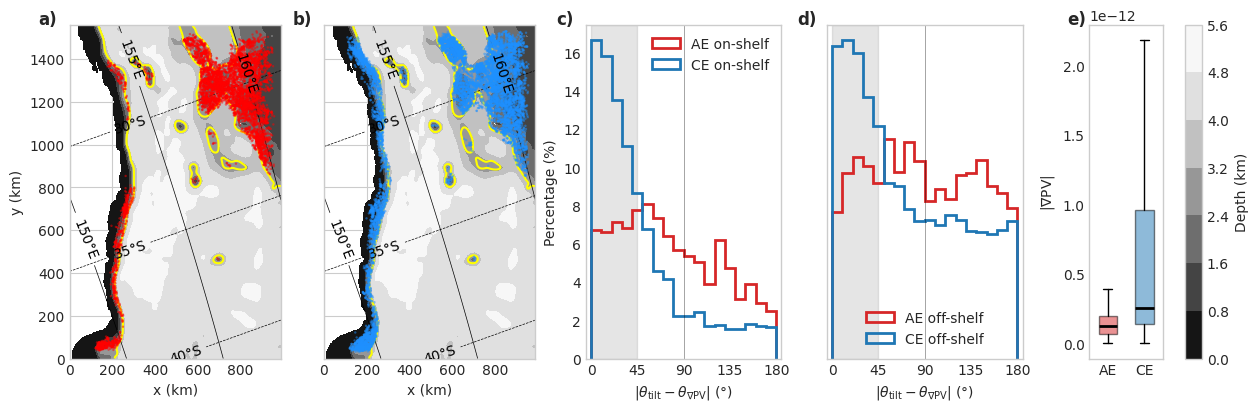

In [21]:
fig, axs = plt.subplots(
    1, 5, figsize=(12.5, 4),
    width_ratios=[1, 1, .8, .8, .3],
    constrained_layout=True
)

# --- AE / CE maps ---
for ax, cyc in zip(axs[:2], ['AE', 'CE']):
    df = topographic[topographic.Cyc == cyc]

    bath = ax.contourf(
        grid.X_grid, grid.Y_grid,
        np.where(grid.mask_rho, grid.h / 1e3, np.nan),
        cmap='Greys_r'
    )

    ax.scatter(df.xc, df.yc, s=3,
               color='r' if cyc == 'AE' else 'dodgerblue',
               alpha=.5, edgecolors='none', zorder=3)

    ax.contour(grid.X_grid, grid.Y_grid, grid.h,
               levels=[MAX_TOPO_DEPTH_m],
               colors='yellow', zorder=2)

    tilt.lat_lon_contours(ax, grid)
    ax.set_xlabel('x (km)')
    if cyc == 'AE':
        ax.set_ylabel('y (km)')
    else:
        ax.set_yticklabels([])

    ax.set_aspect('equal', adjustable='box')


# --- Tilt vs PV gradient: shelf / offshore ---
bins = np.arange(0, 181, 10)

for ax, (name, d) in zip(
    axs[2:4],
    [('on-shelf', topographic[topographic.lon < 154.75]),
     ('off-shelf', topographic[topographic.lon > 154.75])]
):
    for cyc, color in [('AE', 'tab:red'), ('CE', 'tab:blue')]:
        x = d.loc[d.Cyc == cyc, 'dtheta_PV_grad'].dropna()

        ax.hist(
            x,
            bins=bins,
            weights=np.ones(len(x)) * 100 / len(x),
            histtype='step',
            lw=2, color=color, label=f'{cyc} {name}'
        )

    ax.set(
        xlim=(-5, 185),
        xticks=[0, 45, 90, 135, 180],
        xlabel=r'$|\theta_{\rm tilt}-\theta_{\nabla\rm PV}|$ (°)'
    )
    ax.axvspan(0, 45, color='grey', alpha=.2)
    ax.axvline(90, lw=.5, alpha=.5, color='k')
    ax.grid(False)
    ax.legend(frameon=False,
              loc='upper right' if name == 'on-shelf' else 'lower center')

axs[2].set_ylabel('Percentage (%)')
axs[3].set_yticklabels([])


# --- Boxplots ---
ax = axs[4]
bp = ax.boxplot(
    [topographic.loc[topographic.Cyc == cyc, 'PV_grad_mag'].dropna()
     for cyc in ['AE', 'CE']],
    tick_labels=['AE', 'CE'],
    showfliers=False,
    patch_artist=True,
    widths=.5
)

for box, color in zip(bp['boxes'], ['tab:red', 'tab:blue']):
    box.set_facecolor(color)
    box.set_alpha(.5)

for median in bp['medians']:
    median.set_color('k')
    median.set_linewidth(2)

ax.set_ylabel(r'$|\nabla \mathrm{PV}|$')
ax.grid(False)


# Panel labels
for ax, label in zip(axs, ['a)', 'b)', 'c)', 'd)', 'e)']):
    ax.text(-.15 if label!='e)' else -.3, 1.0, label, transform=ax.transAxes,
            fontweight='bold', fontsize=12)

# Bathymetry colourbar
cbar = fig.colorbar(
    bath, ax=axs,
    orientation='vertical',
    fraction=.025,
    pad=.02
)
cbar.set_label('Depth (km)')

plt.show()

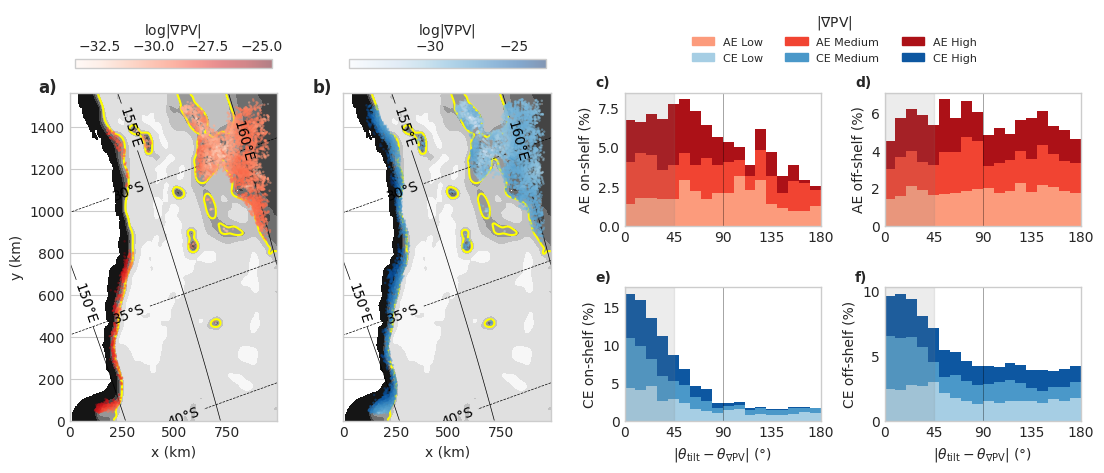

In [104]:
fig = plt.figure(figsize=(11, 4.5), constrained_layout=True)
gs = fig.add_gridspec(
    2, 4,
    width_ratios=[1, 1, .8, .8]
)

axs_map = [
    fig.add_subplot(gs[:, 0]),
    fig.add_subplot(gs[:, 1])
]

axs_hist = np.array([
    [fig.add_subplot(gs[0, 2]), fig.add_subplot(gs[0, 3])],
    [fig.add_subplot(gs[1, 2]), fig.add_subplot(gs[1, 3])]
])

df_data = topographic.copy()

# --- AE / CE maps ---
scats = []

for ax, cyc in zip(axs_map, ['AE', 'CE']):
    df = df_data[df_data.Cyc == cyc]

    bath = ax.contourf(
        grid.X_grid, grid.Y_grid,
        np.where(grid.mask_rho, grid.h / 1e3, np.nan),
        cmap='Greys_r'
    )

    scat = ax.scatter(
        df.xc, df.yc,
        c=np.log(df.PV_grad_mag),
        cmap='Reds' if cyc == 'AE' else 'Blues',
        s=3, alpha=.5, edgecolors='none', zorder=3
    )
    scats.append(scat)

    ax.contour(
        grid.X_grid, grid.Y_grid, grid.h,
        levels=[MAX_TOPO_DEPTH_m],
        colors='yellow'
    )

    tilt.lat_lon_contours(ax, grid)
    ax.set_xlabel('x (km)')
    ax.set_aspect('equal')

axs_map[0].set_ylabel('y (km)')
axs_map[1].set_yticklabels([])

axs_map[0].text(-.15, 1.0, 'a)', transform=axs_map[0].transAxes,
            fontweight='bold', fontsize=12)
axs_map[1].text(-.15, 1.0, 'b)', transform=axs_map[1].transAxes,
            fontweight='bold', fontsize=12)

# --- Scatter colourbars above a) and b) ---
for ax, scat in zip(axs_map, scats):
    cbar = fig.colorbar(
        scat,
        ax=ax,
        location='top',
        pad=0.02,
        fraction=0.03
    )
    cbar.set_label(r'$\log |\nabla \mathrm{PV}|$')


# --- Stacked tilt/PV histograms ---
angle_bins = np.arange(0, 181, 10)

for i, cyc in enumerate(['AE', 'CE']):
    cmap = plt.get_cmap('Reds' if cyc == 'AE' else 'Blues')
    colors = [cmap(.35), cmap(.6), cmap(.85)]

    for j, (name, d) in enumerate([
        ('On-shelf', df_data[df_data.lon < 154.75]),
        ('Off-shelf', df_data[df_data.lon > 154.75])
    ]):
        ax = axs_hist[i, j]

        df = d[d.Cyc == cyc].dropna(
            subset=['dtheta_PV_grad', 'PV_grad_mag']
        ).copy()

        df['PV_bin'] = pd.qcut(
            df.PV_grad_mag, 3,
            labels=['Low', 'Medium', 'High']
        )

        groups = [
            df.loc[df.PV_bin == b, 'dtheta_PV_grad']
            for b in ['Low', 'Medium', 'High']
        ]

        weights = [
            np.ones(len(x)) * 100 / len(df)
            for x in groups
        ]

        ax.hist(
            groups,
            bins=angle_bins,
            weights=weights,
            stacked=True,
            color=colors,
            label=['Low', 'Medium', 'High']
        )

        ax.set_xlim(-5, 185)
        ax.set_xticks([0, 45, 90, 135, 180])
        ax.axvspan(0, 45, color='grey', alpha=.15)
        ax.axvline(90, color='k', lw=.5, alpha=.5)
        ax.grid(False)

        if i == 1:
            ax.set_xlabel(
                r'$|\theta_{\rm tilt}-\theta_{\nabla\rm PV}|$ (°)'
            )
        # else:
        #     ax.set_xticklabels([])

axs_hist[0, 0].set_ylabel('AE on-shelf (%)')
axs_hist[0, 1].set_ylabel('AE off-shelf (%)')
axs_hist[1, 0].set_ylabel('CE on-shelf (%)')
axs_hist[1, 1].set_ylabel('CE off-shelf (%)')

for (l, ax) in zip('cdef',axs_hist.flatten()):
    ax.text(-.15, 1.05, f'{l})', transform=ax.transAxes,
            fontweight='bold', fontsize=10)
    ax.set_xlim(0,180)

from matplotlib.patches import Patch
cmap_ae = plt.get_cmap('Reds')
cmap_ce = plt.get_cmap('Blues')

handles = [
    Patch(color=cmap_ae(.35), label='AE Low'),
    Patch(color=cmap_ce(.35), label='CE Low'),
    Patch(color=cmap_ae(.60), label='AE Medium'),
    Patch(color=cmap_ce(.60), label='CE Medium'),
    Patch(color=cmap_ae(.85), label='AE High'),
    Patch(color=cmap_ce(.85), label='CE High'),
]

fig.legend(
    handles=handles,
    ncol=3,
    frameon=False,
    loc='upper center',
    bbox_to_anchor=(0.76, 1.03),  # centre over histogram section
    fontsize=8,
    title=r'$|\nabla\mathrm{PV}|$'
)

plt.show()

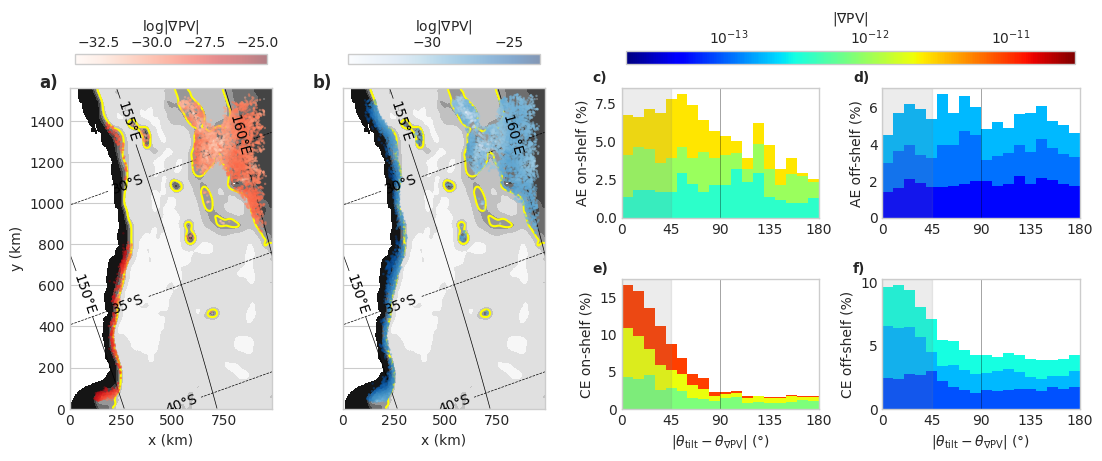

In [107]:
from matplotlib.colors import LogNorm
from matplotlib.cm import ScalarMappable

fig = plt.figure(figsize=(11, 4.5), constrained_layout=True)
gs = fig.add_gridspec(
    2, 4,
    width_ratios=[1, 1, .8, .8]
)

axs_map = [
    fig.add_subplot(gs[:, 0]),
    fig.add_subplot(gs[:, 1])
]

axs_hist = np.array([
    [fig.add_subplot(gs[0, 2]), fig.add_subplot(gs[0, 3])],
    [fig.add_subplot(gs[1, 2]), fig.add_subplot(gs[1, 3])]
])

df_data = topographic.copy()


# ============================================================
# AE / CE maps
# ============================================================

scats = []

for ax, cyc in zip(axs_map, ['AE', 'CE']):
    df = df_data[df_data.Cyc == cyc]

    bath = ax.contourf(
        grid.X_grid, grid.Y_grid,
        np.where(grid.mask_rho, grid.h / 1e3, np.nan),
        cmap='Greys_r'
    )

    scat = ax.scatter(
        df.xc, df.yc,
        c=np.log(df.PV_grad_mag),
        cmap='Reds' if cyc == 'AE' else 'Blues',
        s=3, alpha=.5, edgecolors='none', zorder=3
    )
    scats.append(scat)

    ax.contour(
        grid.X_grid, grid.Y_grid, grid.h,
        levels=[MAX_TOPO_DEPTH_m],
        colors='yellow'
    )

    tilt.lat_lon_contours(ax, grid)
    ax.set_xlabel('x (km)')
    ax.set_aspect('equal')

axs_map[0].set_ylabel('y (km)')
axs_map[1].set_yticklabels([])

axs_map[0].text(
    -.15, 1.0, 'a)',
    transform=axs_map[0].transAxes,
    fontweight='bold', fontsize=12
)

axs_map[1].text(
    -.15, 1.0, 'b)',
    transform=axs_map[1].transAxes,
    fontweight='bold', fontsize=12
)


# --- Map colourbars ---
for ax, scat in zip(axs_map, scats):
    cbar = fig.colorbar(
        scat,
        ax=ax,
        location='top',
        pad=0.02,
        fraction=0.03
    )
    cbar.set_label(r'$\log |\nabla \mathrm{PV}|$')


# ============================================================
# Shared PV colour scale for 2x2 histograms
# ============================================================

pv = df_data.PV_grad_mag
pv = pv[np.isfinite(pv) & (pv > 0)]

norm_pv = LogNorm(
    vmin=pv.quantile(.01),
    vmax=pv.quantile(.99)
)

cmap_pv = plt.get_cmap('jet')


# ============================================================
# Stacked tilt / PV histograms
# ============================================================

angle_bins = np.arange(0, 181, 10)

for i, cyc in enumerate(['AE', 'CE']):

    for j, (name, d) in enumerate([
        ('On-shelf', df_data[df_data.lon < 154.75]),
        ('Off-shelf', df_data[df_data.lon > 154.75])
    ]):

        ax = axs_hist[i, j]

        df = d[d.Cyc == cyc].dropna(
            subset=['dtheta_PV_grad', 'PV_grad_mag']
        ).copy()

        # Separate terciles for each AE/CE + shelf/off-shelf population
        df['PV_bin'] = pd.qcut(
            df.PV_grad_mag,
            3,
            labels=['Low', 'Medium', 'High']
        )

        groups = []
        colors = []

        for b in ['Low', 'Medium', 'High']:
            df_bin = df[df.PV_bin == b]

            groups.append(df_bin.dtheta_PV_grad)

            # Actual PV magnitude represented by this tercile
            pv_rep = df_bin.PV_grad_mag.median()

            # Same colour scale for every panel
            colors.append(cmap_pv(norm_pv(pv_rep)))

        weights = [
            np.ones(len(x)) * 100 / len(df)
            for x in groups
        ]

        ax.hist(
            groups,
            bins=angle_bins,
            weights=weights,
            stacked=True,
            color=colors
        )

        ax.set_xlim(0, 180)
        ax.set_xticks([0, 45, 90, 135, 180])

        ax.axvspan(
            0, 45,
            color='grey',
            alpha=.15
        )

        ax.axvline(
            90,
            color='k',
            lw=.5,
            alpha=.5
        )

        ax.grid(False)

        if i == 1:
            ax.set_xlabel(
                r'$|\theta_{\rm tilt}-\theta_{\nabla\rm PV}|$ (°)'
            )


# --- Labels ---
axs_hist[0, 0].set_ylabel('AE on-shelf (%)')
axs_hist[0, 1].set_ylabel('AE off-shelf (%)')
axs_hist[1, 0].set_ylabel('CE on-shelf (%)')
axs_hist[1, 1].set_ylabel('CE off-shelf (%)')

for l, ax in zip('cdef', axs_hist.flatten()):
    ax.text(
        -.15, 1.05, f'{l})',
        transform=ax.transAxes,
        fontweight='bold',
        fontsize=10
    )


# ============================================================
# Shared horizontal PV colourbar over the 2x2
# ============================================================

sm = ScalarMappable(
    norm=norm_pv,
    cmap=cmap_pv
)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axs_hist.ravel().tolist(),
    location='top',
    orientation='horizontal',
    pad=0.02,
    fraction=0.04,
    aspect=35
)

cbar.set_label(r'$|\nabla \mathrm{PV}|$')


plt.show()

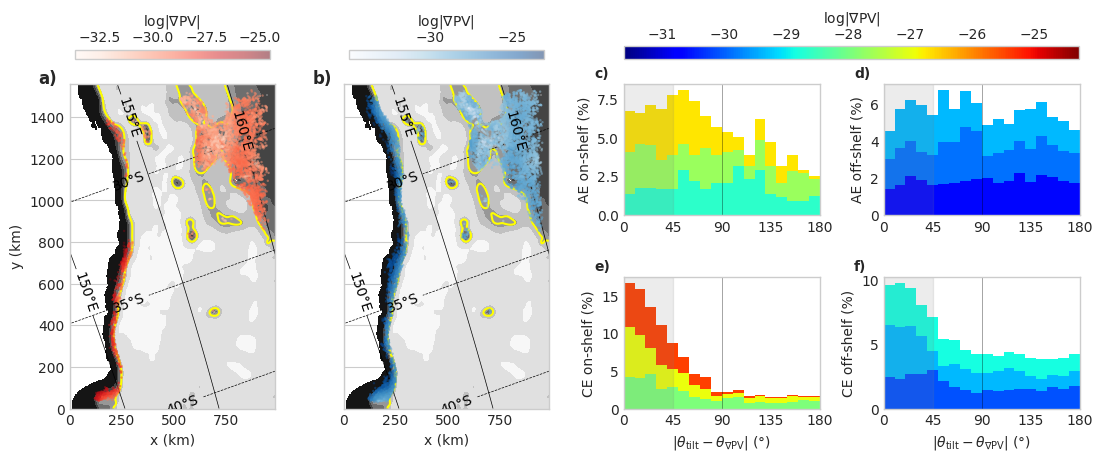

In [109]:
from matplotlib.colors import LogNorm
from matplotlib.cm import ScalarMappable

fig = plt.figure(figsize=(11, 4.5), constrained_layout=True)
gs = fig.add_gridspec(
    2, 4,
    width_ratios=[1, 1, .8, .8]
)

axs_map = [
    fig.add_subplot(gs[:, 0]),
    fig.add_subplot(gs[:, 1])
]

axs_hist = np.array([
    [fig.add_subplot(gs[0, 2]), fig.add_subplot(gs[0, 3])],
    [fig.add_subplot(gs[1, 2]), fig.add_subplot(gs[1, 3])]
])

df_data = topographic.copy()


# ============================================================
# AE / CE maps
# ============================================================

scats = []

for ax, cyc in zip(axs_map, ['AE', 'CE']):
    df = df_data[df_data.Cyc == cyc]

    bath = ax.contourf(
        grid.X_grid, grid.Y_grid,
        np.where(grid.mask_rho, grid.h / 1e3, np.nan),
        cmap='Greys_r'
    )

    scat = ax.scatter(
        df.xc, df.yc,
        c=np.log(df.PV_grad_mag),
        cmap='Reds' if cyc == 'AE' else 'Blues',
        s=3, alpha=.5, edgecolors='none', zorder=3
    )
    scats.append(scat)

    ax.contour(
        grid.X_grid, grid.Y_grid, grid.h,
        levels=[MAX_TOPO_DEPTH_m],
        colors='yellow'
    )

    tilt.lat_lon_contours(ax, grid)
    ax.set_xlabel('x (km)')
    ax.set_aspect('equal')

axs_map[0].set_ylabel('y (km)')
axs_map[1].set_yticklabels([])

axs_map[0].text(
    -.15, 1.0, 'a)',
    transform=axs_map[0].transAxes,
    fontweight='bold', fontsize=12
)

axs_map[1].text(
    -.15, 1.0, 'b)',
    transform=axs_map[1].transAxes,
    fontweight='bold', fontsize=12
)


# --- Map colourbars ---
for ax, scat in zip(axs_map, scats):
    cbar = fig.colorbar(
        scat,
        ax=ax,
        location='top',
        pad=0.02,
        fraction=0.03
    )
    cbar.set_label(r'$\log |\nabla \mathrm{PV}|$')


# ============================================================
# Shared PV colour scale for 2x2 histograms
# ============================================================

from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

pv = df_data.PV_grad_mag
pv = pv[np.isfinite(pv) & (pv > 0)]

log_pv = np.log(pv)

norm_pv = Normalize(
    vmin=log_pv.quantile(.01),
    vmax=log_pv.quantile(.99)
)

cmap_pv = plt.get_cmap('jet')


# ============================================================
# Stacked tilt / PV histograms
# ============================================================

angle_bins = np.arange(0, 181, 10)

for i, cyc in enumerate(['AE', 'CE']):

    for j, (name, d) in enumerate([
        ('On-shelf', df_data[df_data.lon < 154.75]),
        ('Off-shelf', df_data[df_data.lon > 154.75])
    ]):

        ax = axs_hist[i, j]

        df = d[d.Cyc == cyc].dropna(
            subset=['dtheta_PV_grad', 'PV_grad_mag']
        ).copy()

        # Separate terciles for each AE/CE + shelf/off-shelf population
        df['PV_bin'] = pd.qcut(
            df.PV_grad_mag,
            3,
            labels=['Low', 'Medium', 'High']
        )

        groups = []
        colors = []

        for b in ['Low', 'Medium', 'High']:
            df_bin = df[df.PV_bin == b]

            groups.append(df_bin.dtheta_PV_grad)

            # Actual PV magnitude represented by this tercile
            pv_rep = np.log(df_bin.PV_grad_mag).median()
            colors.append(cmap_pv(norm_pv(pv_rep)))

        weights = [
            np.ones(len(x)) * 100 / len(df)
            for x in groups
        ]

        ax.hist(
            groups,
            bins=angle_bins,
            weights=weights,
            stacked=True,
            color=colors
        )

        ax.set_xlim(0, 180)
        ax.set_xticks([0, 45, 90, 135, 180])

        ax.axvspan(
            0, 45,
            color='grey',
            alpha=.15
        )

        ax.axvline(
            90,
            color='k',
            lw=.5,
            alpha=.5
        )

        ax.grid(False)

        if i == 1:
            ax.set_xlabel(
                r'$|\theta_{\rm tilt}-\theta_{\nabla\rm PV}|$ (°)'
            )


# --- Labels ---
axs_hist[0, 0].set_ylabel('AE on-shelf (%)')
axs_hist[0, 1].set_ylabel('AE off-shelf (%)')
axs_hist[1, 0].set_ylabel('CE on-shelf (%)')
axs_hist[1, 1].set_ylabel('CE off-shelf (%)')

for l, ax in zip('cdef', axs_hist.flatten()):
    ax.text(
        -.15, 1.05, f'{l})',
        transform=ax.transAxes,
        fontweight='bold',
        fontsize=10
    )


# ============================================================
# Shared horizontal PV colourbar over the 2x2
# ============================================================

sm = ScalarMappable(
    norm=norm_pv,
    cmap=cmap_pv
)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axs_hist.ravel().tolist(),
    location='top',
    orientation='horizontal',
    pad=0.02,
    fraction=0.04,
    aspect=35
)

cbar.set_label(r'$\log |\nabla \mathrm{PV}|$')


plt.show()

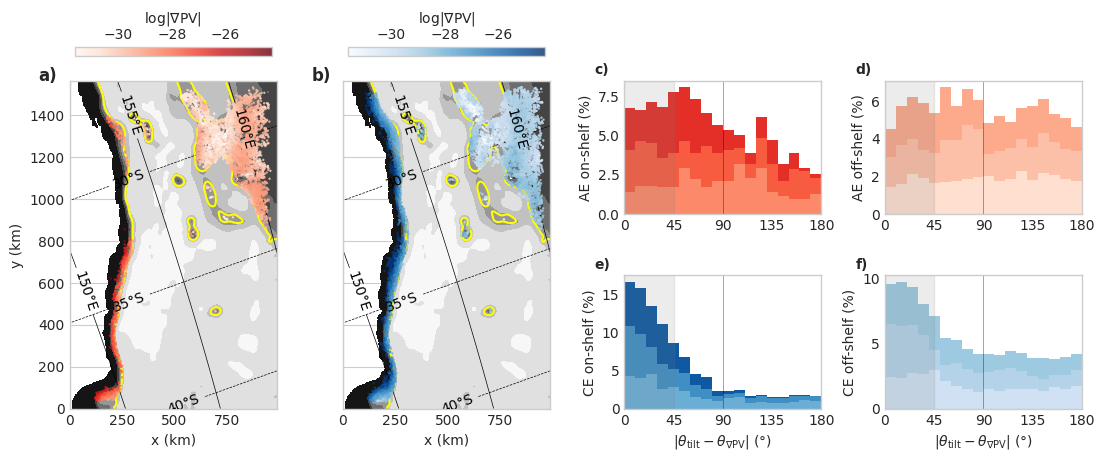

In [111]:
from matplotlib.colors import Normalize

fig = plt.figure(figsize=(11, 4.5), constrained_layout=True)
gs = fig.add_gridspec(
    2, 4,
    width_ratios=[1, 1, .8, .8]
)

axs_map = [
    fig.add_subplot(gs[:, 0]),
    fig.add_subplot(gs[:, 1])
]

axs_hist = np.array([
    [fig.add_subplot(gs[0, 2]), fig.add_subplot(gs[0, 3])],
    [fig.add_subplot(gs[1, 2]), fig.add_subplot(gs[1, 3])]
])

df_data = topographic.copy()


# --- shared log(PV) normalization ---
pv = df_data.PV_grad_mag
pv = pv[np.isfinite(pv) & (pv > 0)]
log_pv = np.log(pv)

norm_pv = Normalize(
    vmin=log_pv.quantile(.01),
    vmax=log_pv.quantile(.99)
)


# ============================================================
# AE / CE maps
# ============================================================

scats = []

for ax, cyc in zip(axs_map, ['AE', 'CE']):
    df = df_data[df_data.Cyc == cyc]

    ax.contourf(
        grid.X_grid, grid.Y_grid,
        np.where(grid.mask_rho, grid.h / 1e3, np.nan),
        cmap='Greys_r'
    )

    scat = ax.scatter(
        df.xc, df.yc,
        c=np.log(df.PV_grad_mag),
        cmap='Reds' if cyc == 'AE' else 'Blues',
        norm=norm_pv,
        s=3, alpha=.8, edgecolors='none', zorder=3
    )
    scats.append(scat)

    ax.contour(
        grid.X_grid, grid.Y_grid, grid.h,
        levels=[MAX_TOPO_DEPTH_m],
        colors='yellow'
    )

    tilt.lat_lon_contours(ax, grid)
    ax.set_xlabel('x (km)')
    ax.set_aspect('equal')

axs_map[0].set_ylabel('y (km)')
axs_map[1].set_yticklabels([])

for l, ax in zip('ab', axs_map):
    ax.text(
        -.15, 1.0, f'{l})',
        transform=ax.transAxes,
        fontweight='bold', fontsize=12
    )


# --- Map colourbars ---
for ax, scat in zip(axs_map, scats):
    cbar = fig.colorbar(
        scat,
        ax=ax,
        location='top',
        pad=0.02,
        fraction=0.03
    )
    cbar.set_label(r'$\log |\nabla \mathrm{PV}|$')


# ============================================================
# Stacked tilt / PV histograms
# ============================================================

angle_bins = np.arange(0, 181, 10)

for i, cyc in enumerate(['AE', 'CE']):

    cmap = plt.get_cmap('Reds' if cyc == 'AE' else 'Blues')

    for j, (name, d) in enumerate([
        ('On-shelf', df_data[df_data.lon < 154.75]),
        ('Off-shelf', df_data[df_data.lon > 154.75])
    ]):

        ax = axs_hist[i, j]

        df = d[d.Cyc == cyc].dropna(
            subset=['dtheta_PV_grad', 'PV_grad_mag']
        ).copy()

        # separate terciles within each panel
        df['PV_bin'] = pd.qcut(
            df.PV_grad_mag,
            3,
            labels=['Low', 'Medium', 'High']
        )

        groups = []
        colors = []

        for b in ['Low', 'Medium', 'High']:
            df_bin = df[df.PV_bin == b]

            groups.append(df_bin.dtheta_PV_grad)

            # colour based on actual median log(PV)
            pv_rep = np.log(df_bin.PV_grad_mag).median()
            colors.append(cmap(norm_pv(pv_rep)))

        weights = [
            np.ones(len(x)) * 100 / len(df)
            for x in groups
        ]

        ax.hist(
            groups,
            bins=angle_bins,
            weights=weights,
            stacked=True,
            color=colors
        )

        ax.set_xlim(0, 180)
        ax.set_xticks([0, 45, 90, 135, 180])

        ax.axvspan(0, 45, color='grey', alpha=.15)
        ax.axvline(90, color='k', lw=.5, alpha=.5)
        ax.grid(False)

        if i == 1:
            ax.set_xlabel(
                r'$|\theta_{\rm tilt}-\theta_{\nabla\rm PV}|$ (°)'
            )


axs_hist[0, 0].set_ylabel('AE on-shelf (%)')
axs_hist[0, 1].set_ylabel('AE off-shelf (%)')
axs_hist[1, 0].set_ylabel('CE on-shelf (%)')
axs_hist[1, 1].set_ylabel('CE off-shelf (%)')

for l, ax in zip('cdef', axs_hist.flatten()):
    ax.text(
        -.15, 1.05, f'{l})',
        transform=ax.transAxes,
        fontweight='bold',
        fontsize=10
    )

plt.show()

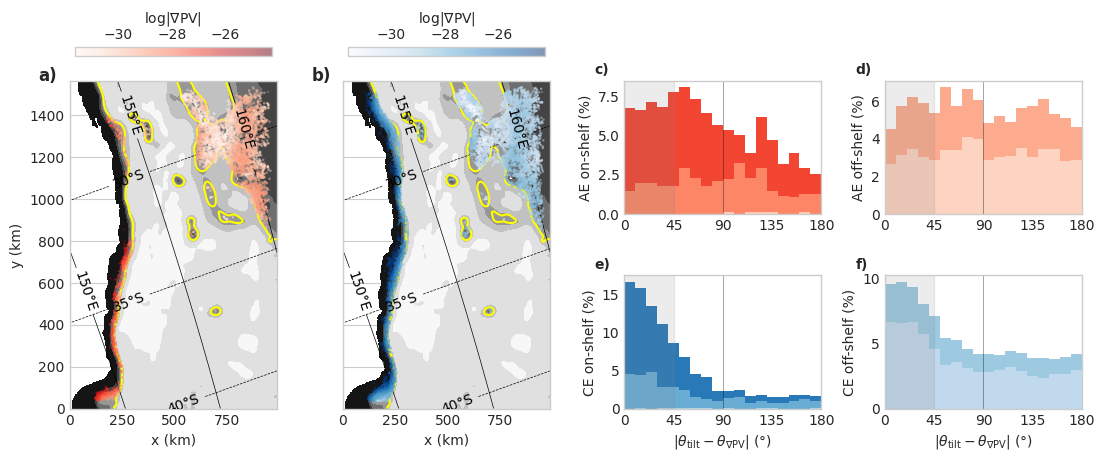

In [119]:
from matplotlib.colors import Normalize

fig = plt.figure(figsize=(11, 4.5), constrained_layout=True)
gs = fig.add_gridspec(
    2, 4,
    width_ratios=[1, 1, .8, .8]
)

axs_map = [
    fig.add_subplot(gs[:, 0]),
    fig.add_subplot(gs[:, 1])
]

axs_hist = np.array([
    [fig.add_subplot(gs[0, 2]), fig.add_subplot(gs[0, 3])],
    [fig.add_subplot(gs[1, 2]), fig.add_subplot(gs[1, 3])]
])

df_data = topographic.copy()


# --- shared log(PV) normalization ---
pv = df_data.PV_grad_mag
pv = pv[np.isfinite(pv) & (pv > 0)]
log_pv = np.log(pv)

norm_pv = Normalize(
    vmin=log_pv.quantile(.01),
    vmax=log_pv.quantile(.99)
)


# ============================================================
# AE / CE maps
# ============================================================

scats = []

for ax, cyc in zip(axs_map, ['AE', 'CE']):
    df = df_data[df_data.Cyc == cyc]

    ax.contourf(
        grid.X_grid, grid.Y_grid,
        np.where(grid.mask_rho, grid.h / 1e3, np.nan),
        cmap='Greys_r'
    )

    scat = ax.scatter(
        df.xc, df.yc,
        c=np.log(df.PV_grad_mag),
        cmap='Reds' if cyc == 'AE' else 'Blues',
        norm=norm_pv,
        s=3, alpha=.5, edgecolors='none', zorder=3
    )
    scats.append(scat)

    ax.contour(
        grid.X_grid, grid.Y_grid, grid.h,
        levels=[MAX_TOPO_DEPTH_m],
        colors='yellow'
    )

    tilt.lat_lon_contours(ax, grid)
    ax.set_xlabel('x (km)')
    ax.set_aspect('equal')

axs_map[0].set_ylabel('y (km)')
axs_map[1].set_yticklabels([])

for l, ax in zip('ab', axs_map):
    ax.text(
        -.15, 1.0, f'{l})',
        transform=ax.transAxes,
        fontweight='bold', fontsize=12
    )


# --- Map colourbars ---
for ax, scat in zip(axs_map, scats):
    cbar = fig.colorbar(
        scat,
        ax=ax,
        location='top',
        pad=0.02,
        fraction=0.03
    )
    cbar.set_label(r'$\log |\nabla \mathrm{PV}|$')


# ============================================================
# Stacked tilt / PV histograms
# ============================================================

angle_bins = np.arange(0, 181, 10)

for i, cyc in enumerate(['AE', 'CE']):

    cmap = plt.get_cmap('Reds' if cyc == 'AE' else 'Blues')

    # --------------------------------------------------------
    # Define PV tercile thresholds from ON-SHELF data only
    # --------------------------------------------------------
    df_on = df_data[
        (df_data.Cyc == cyc) &
        (df_data.lon < 154.75)
    ].dropna(subset=['dtheta_PV_grad', 'PV_grad_mag']).copy()

    q1, q2 = df_on.PV_grad_mag.quantile([.005, .35]) #1/3, 2/3

    pv_edges = [-np.inf, q1, q2, np.inf]

    # --------------------------------------------------------
    # Apply same thresholds to on-shelf + off-shelf
    # --------------------------------------------------------
    for j, (name, d) in enumerate([
        ('On-shelf', df_data[df_data.lon < 154.75]),
        ('Off-shelf', df_data[df_data.lon > 154.75])
    ]):

        ax = axs_hist[i, j]

        df = d[d.Cyc == cyc].dropna(
            subset=['dtheta_PV_grad', 'PV_grad_mag']
        ).copy()

        df['PV_bin'] = pd.cut(
            df.PV_grad_mag,
            bins=pv_edges,
            labels=['Low', 'Medium', 'High']
        )

        groups = []
        colors = []

        for b in ['Low', 'Medium', 'High']:

            df_bin = df[df.PV_bin == b]

            groups.append(df_bin.dtheta_PV_grad)

            # actual median log(PV) controls colour
            pv_rep = np.log(df_bin.PV_grad_mag).median()
            colors.append(cmap(norm_pv(pv_rep)))

        weights = [
            np.ones(len(x)) * 100 / len(df)
            for x in groups
        ]

        ax.hist(
            groups,
            bins=angle_bins,
            weights=weights,
            stacked=True,
            color=colors
        )

        ax.set_xlim(0, 180)
        ax.set_xticks([0, 45, 90, 135, 180])

        ax.axvspan(0, 45, color='grey', alpha=.15)
        ax.axvline(90, color='k', lw=.5, alpha=.5)
        ax.grid(False)

        if i == 1:
            ax.set_xlabel(
                r'$|\theta_{\rm tilt}-\theta_{\nabla\rm PV}|$ (°)'
            )


axs_hist[0, 0].set_ylabel('AE on-shelf (%)')
axs_hist[0, 1].set_ylabel('AE off-shelf (%)')
axs_hist[1, 0].set_ylabel('CE on-shelf (%)')
axs_hist[1, 1].set_ylabel('CE off-shelf (%)')

for l, ax in zip('cdef', axs_hist.flatten()):
    ax.text(
        -.15, 1.05, f'{l})',
        transform=ax.transAxes,
        fontweight='bold',
        fontsize=10
    )

plt.show()

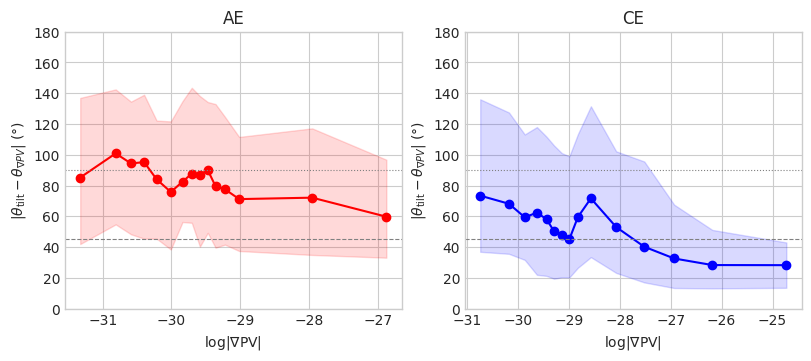

In [97]:
fig, axs = plt.subplots(1, 2, figsize=(8, 3.5), constrained_layout=True)

for ax, cyc, color in zip(axs, ['AE', 'CE'], ['r', 'b']):

    df = topographic[
        (topographic.Cyc == cyc)
    ].dropna(subset=['PV_grad_mag', 'dtheta_PV_grad', 'TiltDis']).copy()

    df['logPV'] = np.log(df.PV_grad_mag)

    # equal-population bins
    df['PV_bin'] = pd.qcut(df.logPV, 15, duplicates='drop')

    stats = (
        df.groupby('PV_bin', observed=True)
        .agg(
            x=('logPV', 'median'),
            angle=('dtheta_PV_grad', 'median'),
            q25=('dtheta_PV_grad', lambda x: x.quantile(.25)),
            q75=('dtheta_PV_grad', lambda x: x.quantile(.75)),
            n=('dtheta_PV_grad', 'size')
        )
    )

    ax.plot(stats.x, stats.angle, '-o', color=color)
    ax.fill_between(
        stats.x, stats.q25, stats.q75,
        color=color, alpha=.15
    )

    ax.axhline(45, color='0.5', ls='--', lw=.8)
    ax.axhline(90, color='0.5', ls=':', lw=.8)

    ax.set(
        xlabel=r'$\log |\nabla \mathrm{PV}|$',
        ylabel=r'$|\theta_{\rm tilt}-\theta_{\nabla PV}|$ (°)',
        title=cyc,
        ylim=(0, 180)
    )

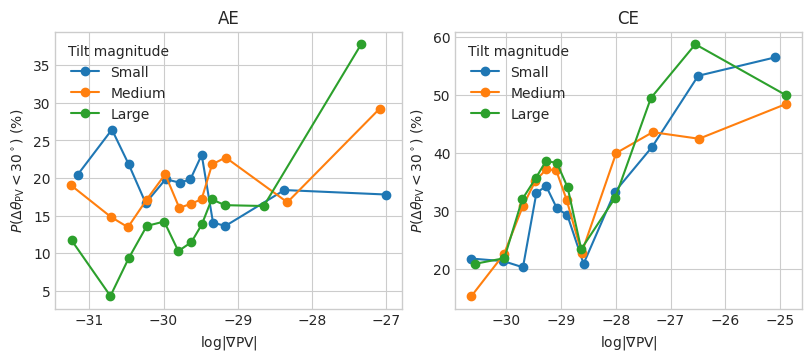

In [99]:
df['Tilt_bin'] = pd.qcut(
    df.TiltDis,
    3,
    labels=['Small tilt', 'Medium tilt', 'Large tilt']
)
fig, axs = plt.subplots(1, 2, figsize=(8, 3.5), constrained_layout=True)

for ax, cyc in zip(axs, ['AE', 'CE']):

    d = df[df.Cyc == cyc].copy()

    d['Tilt_bin'] = pd.qcut(
        d.TiltDis,
        3,
        labels=['Small', 'Medium', 'Large']
    )

    d['PV_bin'] = pd.qcut(d.logPV, 12, duplicates='drop')

    for tilt_bin in ['Small', 'Medium', 'Large']:

        dd = d[d.Tilt_bin == tilt_bin]

        stats = (
            dd.groupby('PV_bin', observed=True)
            .agg(
                x=('logPV', 'median'),
                p=('aligned', 'mean')
            )
        )

        ax.plot(
            stats.x,
            100 * stats.p,
            '-o',
            label=tilt_bin
        )

    ax.set(
        title=cyc,
        xlabel=r'$\log |\nabla \mathrm{PV}|$',
        ylabel=r'$P(\Delta\theta_{\rm PV}<30^\circ)$ (%)'
    )

    ax.legend(title='Tilt magnitude', frameon=False)

## 5. Select equally sized candidate sets

The default is three eddies per group. The same eddy may be scientifically useful in more than one group if it spends different parts of its lifetime offshore and over a slope. Keep such overlap when it illustrates a within-eddy transition; otherwise replace it with the next ranked candidate.

In [12]:
N_PER_GROUP = 5
selected = select_pv_alignment_cases(ranking, n_per_group=N_PER_GROUP)
selected

{'open_ocean_ce': [1856, 1590, 639, 1570, 2027],
 'open_ocean_ae': [150, 1338, 356, 1060, 493],
 'topographic_ce_alignment': [735, 1034, 2155, 1194, 1803],
 'topographic_ae_no_preference': [2517, 2442, 1457, 2790, 396]}

In [13]:
selected_long = pd.DataFrame(
    [(group, eddy) for group, eddies in selected.items() for eddy in eddies],
    columns=['case_group', 'Eddy'],
)
display(selected_long.groupby('Eddy').filter(lambda x: len(x) > 1).sort_values('Eddy'))

,case_group,Eddy


## 6. Direction and bathymetry figures

The first panel shows tilt and total PV-gradient compass bearings without connecting across the artificial 0°/360° boundary. For AEs, green markers show the direction opposite the PV gradient. The second panel shows `dtheta_PV_grad`: 0° is alignment and 180° is opposition. Remaining panels show dominance, component magnitudes, tilt magnitude/depth, and the full track over local bathymetry.

In [14]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [ ]:
for group, eddies in selected.items():
    print(f'\n{group_titles[group]}')
    for eddy_id in eddies:
        track = df_direction[df_direction.Eddy == eddy_id].copy()
        fig, _, _ = plot_pv_alignment_case(
            track, grid, config=config,
            title=f'{group_titles[group]} — {track.Cyc.iloc[0]} eddy {eddy_id}'
)
        plt.show()

## 7. Regime-specific summaries for selected cases

These summaries quantify the directional behaviour visible in each figure. Fractions are calculated only from observations with tilt distance ≥5 km. Day-level values are descriptive repeated observations, not statistically independent samples.

In [ ]:
selected_ids = sorted(set(selected_long.Eddy))
case_rows = []
for eddy_id in selected_ids:
    part = df_direction[df_direction.Eddy == eddy_id]
    for regime_name, mask in {
        'open_ocean_planetary': part.open_ocean_planetary,
        'topographic': part.topographic_strong,
    }.items():
        use = part[mask & part.direction_valid]
        if use.empty:
            continue
        case_rows.append({
            'Eddy': eddy_id, 'Cyc': part.Cyc.iloc[0], 'regime': regime_name,
            'observations': len(use),
            'median_dtheta_deg': use.dtheta_PV_grad.median(),
            'aligned_within_45_fraction': (use.dtheta_PV_grad <= 45).mean(),
            'opposed_within_45_fraction': (use.dtheta_PV_grad >= 135).mean(),
            'median_tilt_km': use.TiltDis.median(),
            'median_depth_m': use.h.median(),
        })
case_summary = pd.DataFrame(case_rows)
display(case_summary.round(3).sort_values(['Cyc', 'Eddy', 'regime']))

## 8. Dominance-threshold sensitivity

A case is stronger if it remains highly ranked when dominance is tightened from 2:1 to 4:1. Failure at 4:1 does not invalidate a 2:1 case, but it indicates that its directional behaviour occurs where planetary and topographic contributions are less cleanly separated.

In [ ]:
strict_config = PVAlignmentConfig(
    smooth_window=config.smooth_window, min_periods=config.min_periods,
    min_lifetime_days=config.min_lifetime_days,
    min_valid_observations=config.min_valid_observations,
    min_regime_observations=config.min_regime_observations,
    min_sustained_run=config.min_sustained_run, dominance_factor=4.0,
    angle_tolerance_deg=config.angle_tolerance_deg,
    min_open_ocean_depth_m=config.min_open_ocean_depth_m,
    min_tilt_distance_km=config.min_tilt_distance_km,
)
_, strict_ranking = rank_pv_alignment_cases(df_eddies, strict_config)
strict_eligible = set(
    zip(
        strict_ranking.loc[strict_ranking.eligible, 'ranking_group'],
        strict_ranking.loc[strict_ranking.eligible, 'Eddy'],
    )
)
sensitivity = selected_long.copy()
sensitivity['eligible_at_4_to_1'] = [
    (row.case_group, row.Eddy) in strict_eligible for row in sensitivity.itertuples()
]
display(sensitivity)

## Interpretation checklist

A strong case should have: (1) sustained rather than isolated alignment/opposition; (2) a clear dominance regime; (3) adequate tilt magnitude and directional coverage; (4) a coherent track over the expected bathymetric setting; (5) simultaneous motion of `TiltDir`, `PV_grad_theta`, and `dtheta_PV_grad`; and (6) no obvious boundary or missing-data artefact.

The figures demonstrate representative evolution, not causality by themselves. The population distributions and threshold sensitivity should accompany any highlighted case so the examples remain tied to the complete eddy census.